In [1]:
%load_ext autoreload
%autoreload 2

In [29]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import json
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pickle
import seaborn as sns
from tqdm import tqdm
from bosperrus import *
plt.rcParams['svg.fonttype'] = 'none'
#plt.rcParams['figure.facecolor'] = "#D9D9D9"

from pathlib import Path
sys.path.insert(0, str((Path("..") / ".." / "src" / "utils").resolve()))
import micron_comparison
import visium_hd

/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
with open("../../fit_palette.json") as f:
    pal = json.load(f)

In [4]:
cmap = "magma"

In [5]:
np.random.seed(41)

In [6]:
measure = "closeness"

In [7]:
with open("../../mibitof_coords/coords.pickle", "rb") as f:
    datasets = pickle.load(f)

In [8]:
dataset = "TNBC_mibitof:p14_labeledcellData.tiff"
coords = datasets[dataset]

In [9]:
coords = coords[(coords[:, 0] < 1500) & (coords[:,1] < 1500)]
subset = coords /  (np.max(coords, axis=0) - np.min(coords, axis=0)) # [(coords[:, 0] < 1000) & (coords[:,1] < 1000)]

In [10]:
G = nx.Graph()
G.add_nodes_from(range(len(subset)))
for n in G.nodes:
    G.nodes[n]["pos"] = subset[n]
edges = delaunay_edges(subset)
G.add_edges_from(edges)

In [11]:
df =  pd.DataFrame(compute_centrality_measures(edges, len(subset), measures=[measure]))
df["distance"] = distance_to_convex_hull(subset)

In [12]:
d = df["distance"]
C_true = df[measure].values   

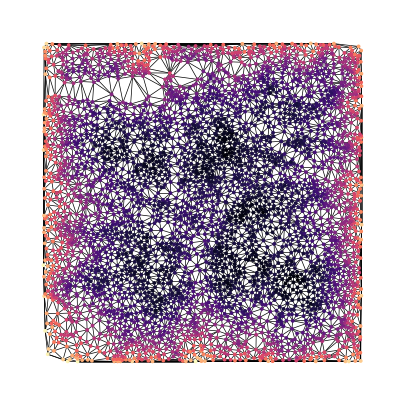

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
pos = nx.get_node_attributes(G, "pos")
edges1 = nx.draw_networkx_edges(G, pos=pos, ax=ax, edge_color="black", width=0.5)
nodes1 = nx.draw_networkx_nodes(G, pos=pos, node_color=C_true, node_size=3, cmap=cmap, ax=ax)
edges1.set_rasterized(True)
nodes1.set_rasterized(True)
plt.axis("square")
plt.axis("off")
plt.savefig("../../result_plots/figure1/fig1_closeness.svg")

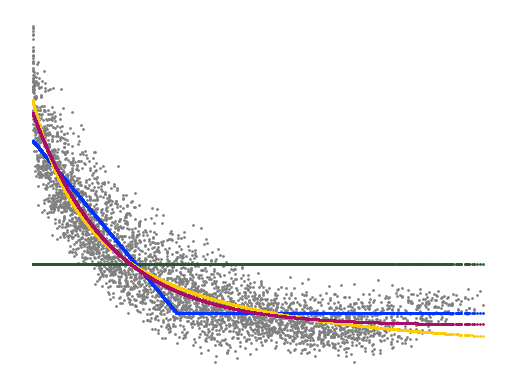

In [20]:
plt.scatter(d, C_true, label="C_true", s=1, color="gray")

for fit in ConstantFit, PiecewiseLinearFit, MichaelisMentenFit, ExponentialSaturationFit:
    f = fit(S_true=C_true, d=d)
    f.fit()
    plt.scatter(d, f.S_model, label=f.name, s=1, color=pal[f.name], rasterized=True)
plt.axis("off")
plt.savefig("../../result_plots/figure1/fig1_fits.svg")

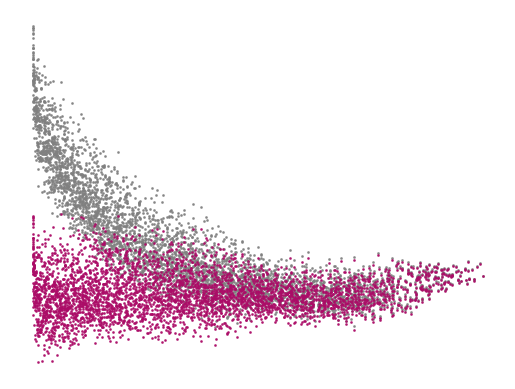

In [25]:
f = Flow.from_distances_and_scores(distances=d, scores=df[["closeness"]])
f.flow()
plt.scatter(d, C_true, label="Closeness", s=1, color="gray", alpha=0.8, rasterized=True)
plt.scatter(d, f.observations["BOSPERRUS corrected closeness"], label="BOSPERRUS corrected closeness", s=1, color=pal[f.best_fits["closeness"].name], alpha=0.8, rasterized=True)
plt.axis("off")
plt.savefig("../../result_plots/figure1/fig1_corrections.svg")

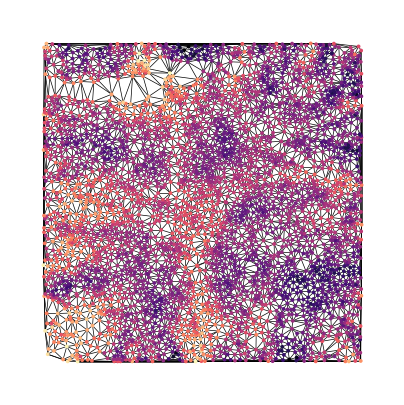

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
pos = nx.get_node_attributes(G, "pos")
edges1 = nx.draw_networkx_edges(G, pos=pos, ax=ax, edge_color="black", width=0.5)
nodes1 = nx.draw_networkx_nodes(G, pos=pos, node_color=f.observations["BOSPERRUS corrected closeness"], node_size=3, cmap=cmap, ax=ax)
edges1.set_rasterized(True)
nodes1.set_rasterized(True)
plt.axis("square")
plt.axis("off")

plt.savefig("../../result_plots/figure1/fig1_corrected_closeness.svg")

In [30]:
VISIUM_BASE = "/home/woody/iwbn/iwbn007h/visium_hd_demo_data"
VISIUM_DATASETS = [
    {"name": "breast_cancer", "title": "Visium HD 8µm Breast cancer (Fixed Frozen)",
     "h5ad": f"{VISIUM_BASE}/Visium_HD_11mm_Human_Breast_Cancer/breast_cancer_008um_filtered.h5ad"}]

adata = visium_hd.read_h5ad(VISIUM_DATASETS[0]["h5ad"])
visium_result = visium_hd.analyze_dataset(VISIUM_DATASETS[0]["h5ad"])

INFO     Creating graph using `None` transform and `1` libraries.                                                  


In [35]:
visium_result["flow"].best_fits['log1p_total_counts'].params['piecewise_linear_b']

np.float64(14.40005592252269)